Loading data...
Dataset shape: (45000, 14)

Preparing data...
Creating preprocessing pipeline...
Training model...

Evaluating model...
Model Evaluation Results:
              precision    recall  f1-score   support

           0       0.94      0.93      0.94      6990
           1       0.77      0.79      0.78      2010

    accuracy                           0.90      9000
   macro avg       0.86      0.86      0.86      9000
weighted avg       0.90      0.90      0.90      9000

Confusion Matrix:
[[6518  472]
 [ 413 1597]]

Visualizing Decision Tree...


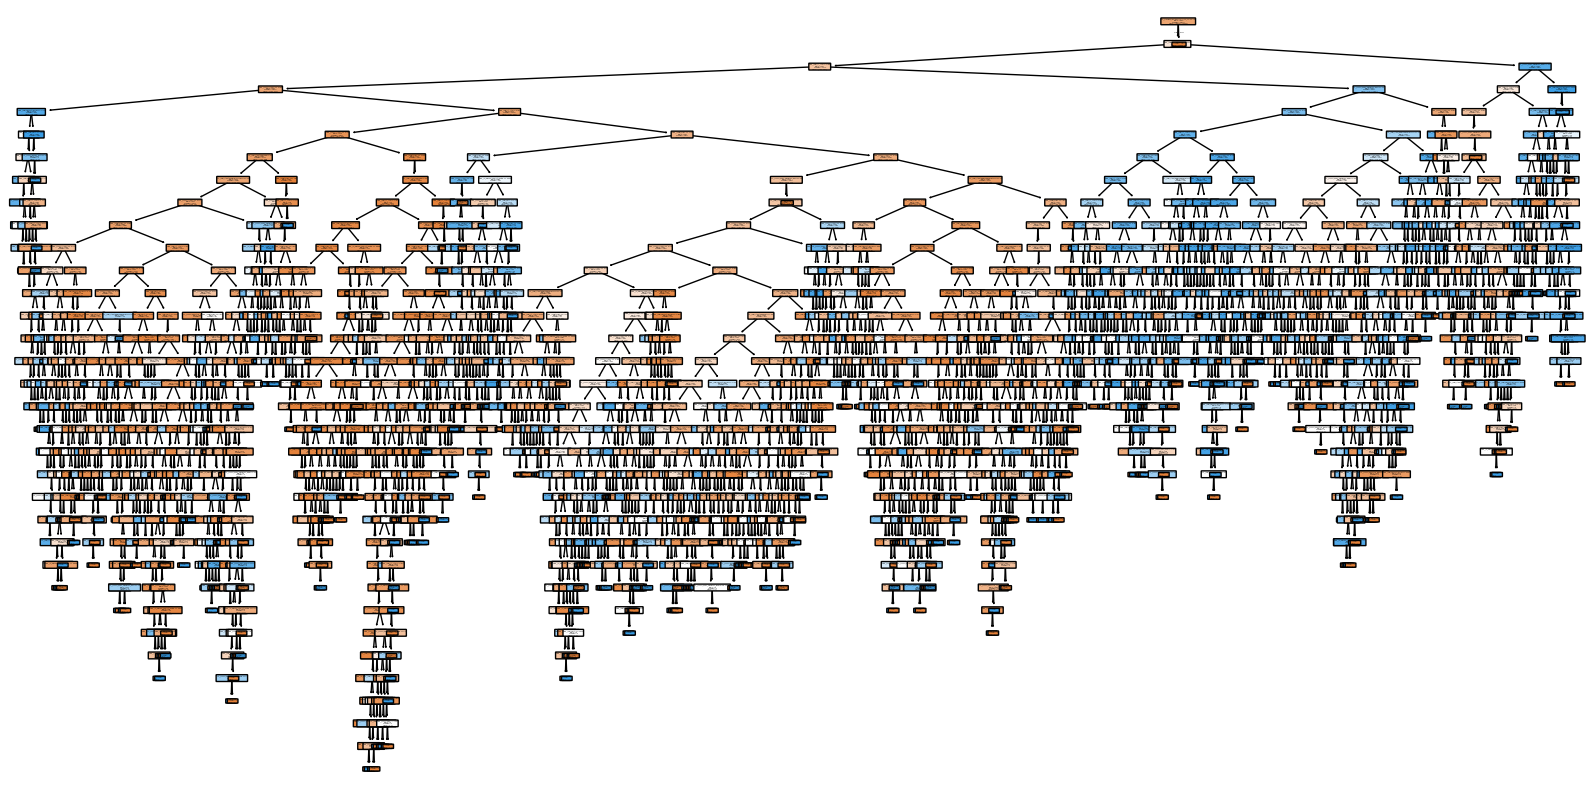


Interactive Prediction Mode
Prediction: 0
Probability: [1. 0.]


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

def loadData():
    return pd.read_csv("data.csv")

def prepareData(df):
    targetColumn = df.columns[-1]
    x = df.drop(columns=[targetColumn])
    y = df[targetColumn]
    return x, y

def createPreprocessor(x):
    numericFeatures = x.select_dtypes(include=["int64", "float64"]).columns
    categoricalFeatures = x.select_dtypes(include=["object"]).columns

    numericTransformer = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]
    )

    categoricalTransformer = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
        ]
    )

    return ColumnTransformer(
        transformers=[
            ("num", numericTransformer, numericFeatures),
            ("cat", categoricalTransformer, categoricalFeatures)
        ]
    )

def trainModel(xTrain, yTrain, preprocessor):
    model = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("classifier", DecisionTreeClassifier(random_state=42))
        ]
    )
    model.fit(xTrain, yTrain)
    return model

def evaluateModel(model, xTest, yTest):
    yPred = model.predict(xTest)
    print("Model Evaluation Results:")
    print("=" * 40)
    print(classification_report(yTest, yPred))
    print("Confusion Matrix:")
    print(confusion_matrix(yTest, yPred))
    return yPred

def visualizeTree(model, featureNames):
    classifier = model.named_steps["classifier"]
    plt.figure(figsize=(20, 10))
    plot_tree(
        classifier,
        feature_names=featureNames,
        filled=True,
        rounded=True
    )
    plt.show()

def interactivePrediction(model, x):
    inputData = {}
    for column in x.columns:
        value = input(f"Enter value for {column}: ")
        inputData[column] = [value]
    inputDf = pd.DataFrame(inputData)
    prediction = model.predict(inputDf)[0]
    probability = model.predict_proba(inputDf)[0]
    print(f"Prediction: {prediction}")
    print(f"Probability: {probability}")

def main():
    print("Loading data...")
    df = loadData()
    print(f"Dataset shape: {df.shape}")

    print("\nPreparing data...")
    x, y = prepareData(df)

    xTrain, xTest, yTrain, yTest = train_test_split(
        x, y, test_size=0.2, random_state=42
    )

    print("Creating preprocessing pipeline...")
    preprocessor = createPreprocessor(xTrain)

    print("Training model...")
    model = trainModel(xTrain, yTrain, preprocessor)

    print("\nEvaluating model...")
    evaluateModel(model, xTest, yTest)

    print("\nVisualizing Decision Tree...")
    processedFeatureNames = model.named_steps["preprocessor"].get_feature_names_out()
    visualizeTree(model, processedFeatureNames)

    print("\nInteractive Prediction Mode")
    interactivePrediction(model, x)

    return model

if __name__ == "__main__":
    main()
